In [ ]:
import pandas as pd

In [ ]:
import kagglehub
path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")

Using Colab cache for faster access to the 'web-page-phishing-detection-dataset' dataset.


In [ ]:
print(path)

/kaggle/input/web-page-phishing-detection-dataset


In [ ]:
df=pd.read_csv("/kaggle/input/web-page-phishing-detection-dataset/dataset_phishing.csv")
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
df

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,448,5396,3980,0,0,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,1,0,0,85,2836,2455493,0,0,4,legitimate


Initial shape: (11430, 89)

--- 2. Cleaning Target Labels ---
Shape after cleaning labels: (11430, 89)


/tmp/ipykernel_3502/766608114.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_data, palette='Set2')


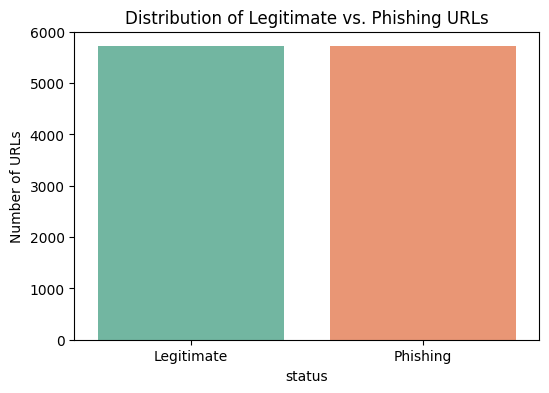


--- 3. Separating Features and Target ---

--- 4. Splitting Data ---
Training features shape: (9144, 87)
Testing features shape: (2286, 87)
Dropping 6 dead features: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']

--- 5. Removing Highly Correlated Features ---
Dropped 2 redundant features.
Final training features shape: (9144, 79)

--- 6. Training XGBoost Model ---
Model training complete.

--- 7. Evaluation ---
Accuracy: 0.9641294838145232

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96      1143
           1       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286


Top 10 Most Important Features:
           Feature  Importance
      google_index    0.616888
         page_rank    0.029313
     nb_hyperlinks    0

/tmp/ipykernel_3502/766608114.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


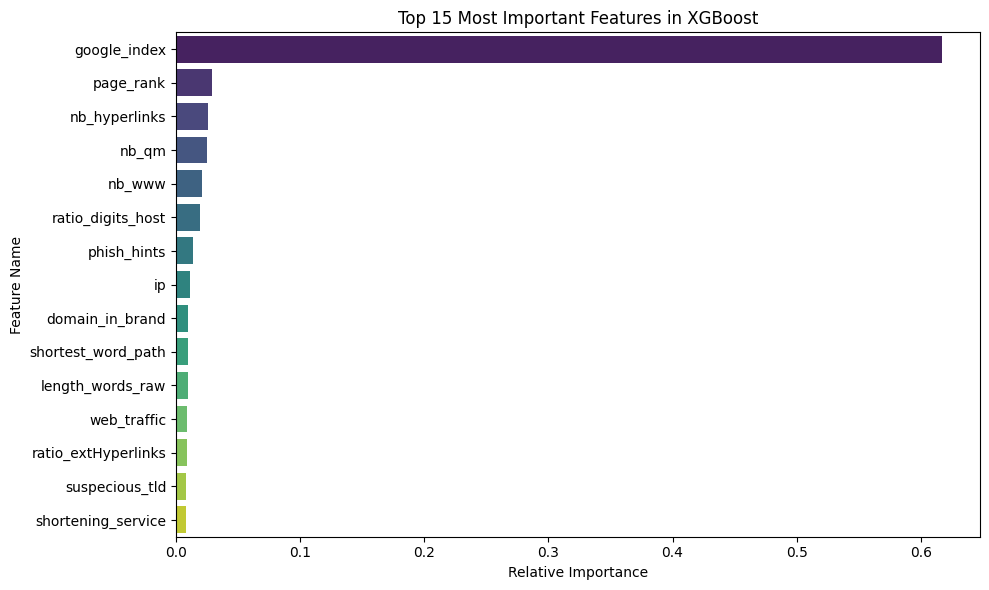

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

print(f"Initial shape: {df.shape}")

print("\n--- 2. Cleaning Target Labels ---")
df['status'] = df['status'].astype(str).str.strip().str.lower()
df['status'] = df['status'].map({'legitimate': 0, 'phishing': 1})


df = df.dropna(subset=['status'])
print(f"Shape after cleaning labels: {df.shape}")

plt.figure(figsize=(6, 4))
plot_data = df['status'].map({0: 'Legitimate', 1: 'Phishing'})

sns.countplot(x=plot_data, palette='Set2')
plt.title('Distribution of Legitimate vs. Phishing URLs')
plt.ylabel('Number of URLs')
plt.show()

print("\n--- 3. Separating Features and Target ---")
if 'url' in df.columns:
    urls = df['url']
    X = df.drop(columns=['status', 'url'])
else:
    X = df.drop(columns=['status'])

y = df['status']

print("\n--- 4. Splitting Data ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

zero_variance_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

if len(zero_variance_cols) > 0:
    print(f"Dropping {len(zero_variance_cols)} dead features: {zero_variance_cols}")
    X_train = X_train.drop(columns=zero_variance_cols)
    X_test = X_test.drop(columns=zero_variance_cols)

print("\n--- 5. Removing Highly Correlated Features ---")
corr_matrix = X_train.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.85
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
X_train_clean = X_train.drop(columns=features_to_drop)
X_test_clean = X_test.drop(columns=features_to_drop)

print(f"Dropped {len(features_to_drop)} redundant features.")
print(f"Final training features shape: {X_train_clean.shape}")

print("\n--- 6. Training XGBoost Model ---")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_clean, y_train)
print("Model training complete.")

print("\n--- 7. Evaluation ---")
y_pred = xgb_model.predict(X_test_clean)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

importances = xgb_model.feature_importances_
feature_names = X_train_clean.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))

sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')

plt.title('Top 15 Most Important Features in XGBoost')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Starting feature count: 81
Dropped 0 dead columns. Remaining: 81
Dropped 2 highly correlated columns. Remaining: 79


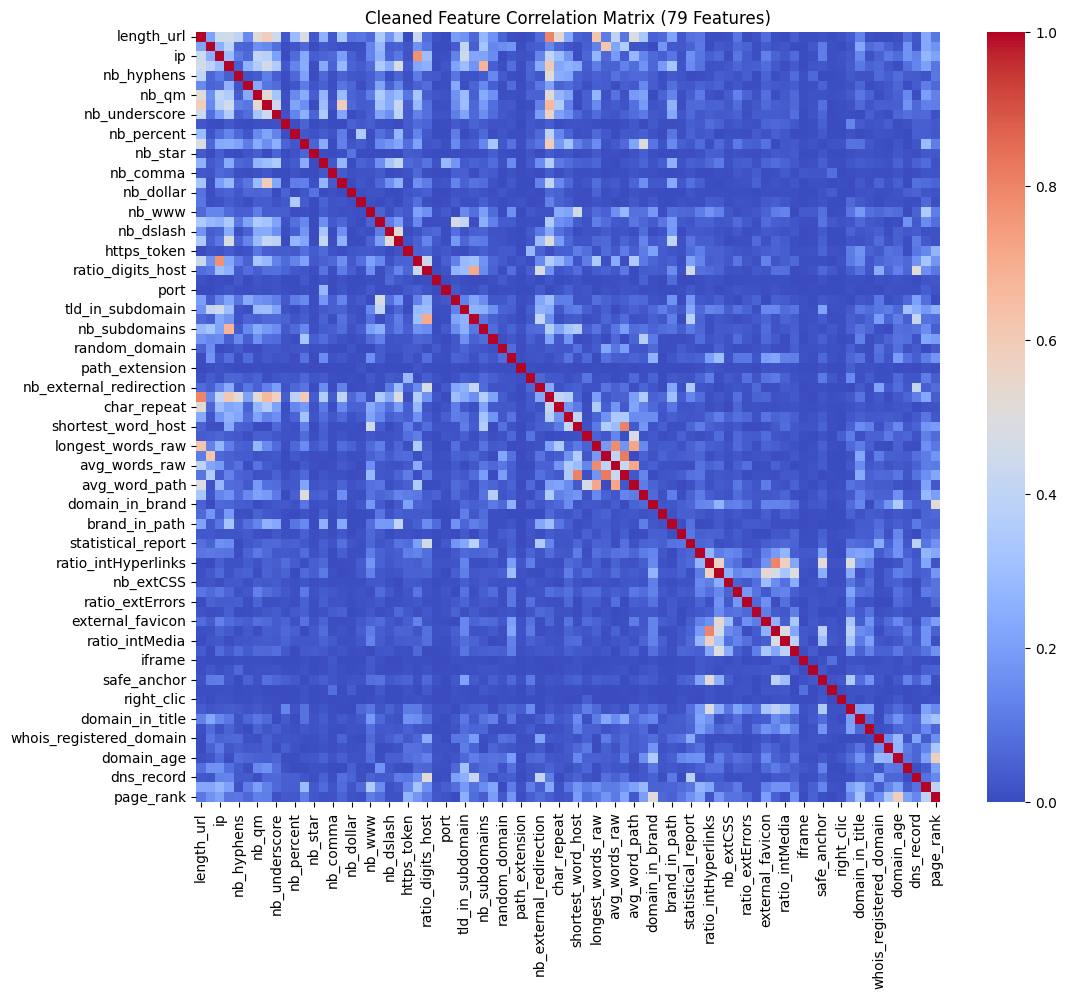

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(f"Starting feature count: {X_train.shape[1]}")

zero_variance_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]
X_train_temp = X_train.drop(columns=zero_variance_cols)
print(f"Dropped {len(zero_variance_cols)} dead columns. Remaining: {X_train_temp.shape[1]}")

corr_matrix = X_train_temp.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
X_train_clean_final = X_train_temp.drop(columns=features_to_drop)

print(f"Dropped {len(features_to_drop)} highly correlated columns. Remaining: {X_train_clean_final.shape[1]}")

plt.figure(figsize=(12, 10))
final_corr_matrix = X_train_clean_final.corr().abs()
sns.heatmap(final_corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.title(f"Cleaned Feature Correlation Matrix ({X_train_clean_final.shape[1]} Features)")
plt.show()

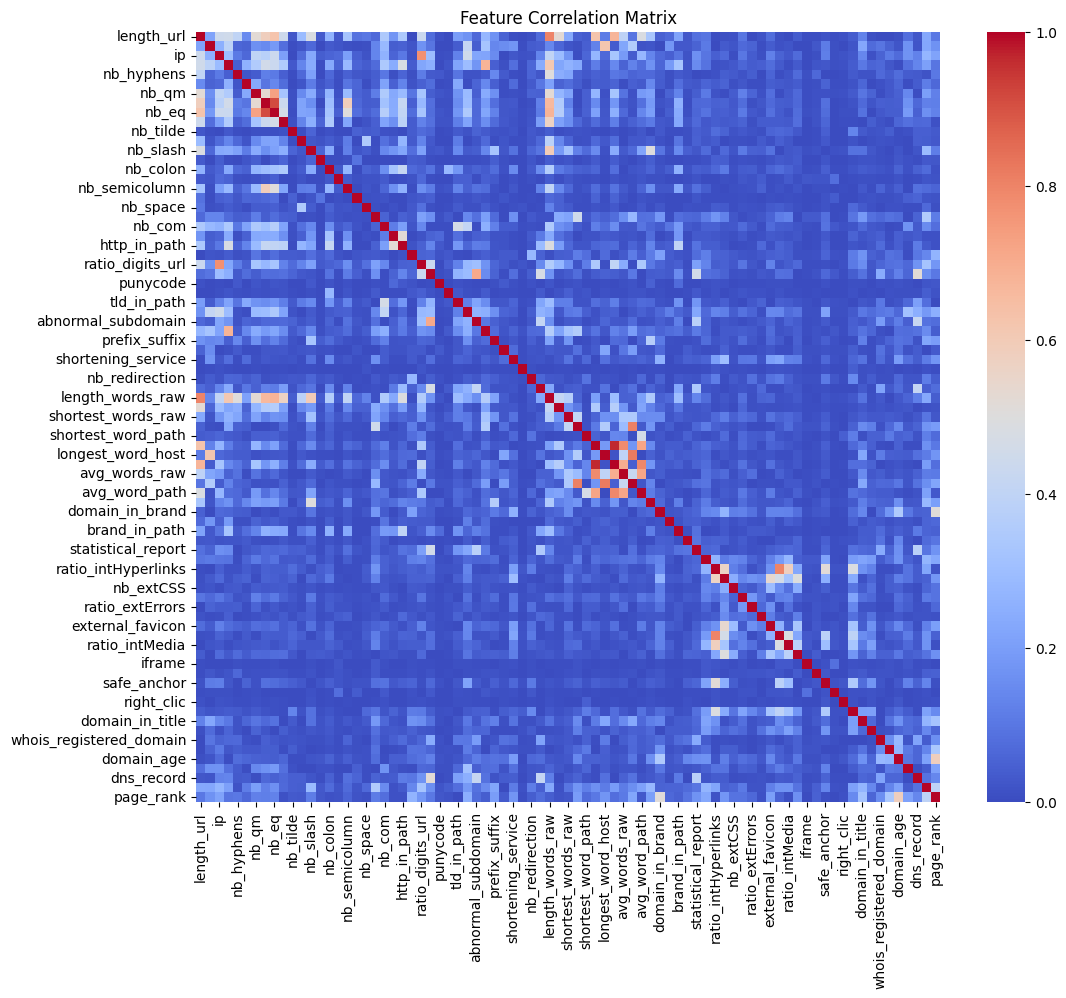

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = X_train.corr().abs()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

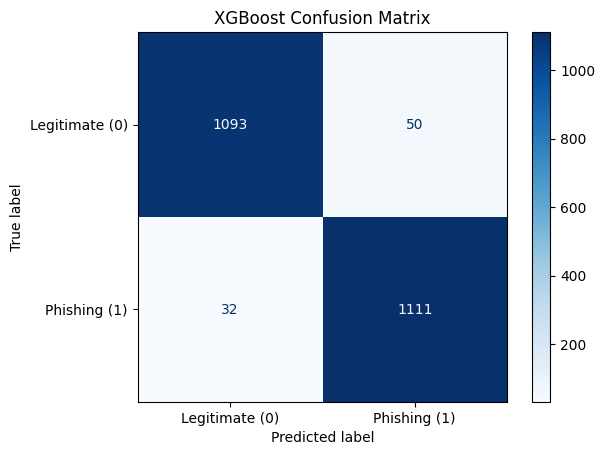

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate (0)', 'Phishing (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. Train & Evaluate Random Forest
# ==========================================
print("\n" + "="*40)
print(" MODEL 2: RANDOM FOREST")
print("="*40)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_clean, y_train)
y_pred_rf = rf_model.predict(X_test_clean)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# ==========================================
# 2. Train & Evaluate Logistic Regression
# ==========================================
print("\n" + "="*40)
print(" MODEL 3: LOGISTIC REGRESSION")
print("="*40)

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_clean, y_train)
y_pred_lr = lr_model.predict(X_test_clean)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# ==========================================
# 3. Quick Comparison Summary
# ==========================================
print("\n" + "="*40)
print(" FINAL ACCURACY COMPARISON")
print("="*40)
print(f"XGBoost:             {accuracy_score(y_test, y_pred):.4f}")
print(f"Random Forest:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")


 MODEL 2: RANDOM FOREST
Accuracy: 0.9615048118985127

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      1143
           1       0.96      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286


 MODEL 3: LOGISTIC REGRESSION
Accuracy: 0.8114610673665792

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      1143
           1       0.80      0.83      0.81      1143

    accuracy                           0.81      2286
   macro avg       0.81      0.81      0.81      2286
weighted avg       0.81      0.81      0.81      2286


 FINAL ACCURACY COMPARISON
XGBoost:             0.9641
Random Forest:       0.9615
Logistic Regression: 0.8115


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
